In [2]:
import polars as pl
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

import pyreadstat as prs
import pygwalker as pyg

import altair as alt
import seaborn as sns
import matplotlib.pyplot as plt

import json

from linearmodels.panel import PanelOLS
from scipy import stats as scipy_stats
import statsmodels.formula.api as smf
from linearmodels.panel.results import compare
import statsmodels.api as sm

from tqdm.notebook import tqdm
from itables import init_notebook_mode

In [3]:
book_colors = {
    'primary': '#2E86AB',    # Steel blue - main data
    'secondary': '#A23B72',  # Magenta - secondary data
    'accent': '#F18F01',     # Orangxe - highlights/warnings
    'success': '#C73E1D',    # Red-orange - thresholds/targets
    'muted': '#6C757D',      # Gray - reference lines
    'light_gray': '#E5E5E5', # Light gray - backgrounds
    'dark_gray': '#4D4D4D'   # Dark gray - text
}

def setup_book_style():
    """Apply consistent styling to matplotlib plots"""
    plt.rcParams.update({
        'figure.figsize': (10, 7),
        'figure.dpi': 100,
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.titleweight': 'bold',
        'axes.labelsize': 14,
        'axes.labelcolor': '#4D4D4D',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.color': '#E5E5E5',
        'legend.fontsize': 11,
        'legend.frameon': False,
        'xtick.labelsize': 11,
        'ytick.labelsize': 11,
    })

setup_book_style()

In [4]:
def plot_event_margins(model, measure_unit = 'RUB'):
    coef_names = [col for col in model.params.index if col.startswith('rel_period')]
    coefs = model.params[coef_names]
    std_errors = model.std_errors[coef_names]
    
    # Parse relative periods from coefficient names
    rel_periods = [int(name.split('_')[2]) for name in coef_names]
    
    # Create DataFrame for plotting
    coef_df = pd.DataFrame({
        'relative_period': rel_periods,
        'estimate': coefs.values,
        'std_error': std_errors.values
    })
    
    # Add reference period (k = -1) with zero effect
    ref_row = pd.DataFrame({
        'relative_period': [-1],
        'estimate': [0],
        'std_error': [0]
    })
    coef_df = pd.concat([coef_df, ref_row], ignore_index=True)
    coef_df = coef_df.sort_values('relative_period').reset_index(drop=True)
    
    # Calculate confidence intervals (95%)
    coef_df['ci_lower'] = coef_df['estimate'] - 1.96 * coef_df['std_error']
    coef_df['ci_upper'] = coef_df['estimate'] + 1.96 * coef_df['std_error']
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Shade pre-treatment region
    ax.axvspan(-6.5, -0.5, alpha=0.15, color=book_colors['light_gray'], zorder=0)
    
    # Reference lines
    ax.axhline(y=0, linestyle='--', color=book_colors['muted'], linewidth=1, alpha=0.8)
    ax.axvline(x=-0.5, linestyle='--', color=book_colors['muted'], linewidth=1, alpha=0.8)

    ax.axvline(x=-1, linestyle='--', color='red', linewidth=1, alpha=0.8)
    ax.axvline(x=1, linestyle='--', color='red', linewidth=1, alpha=0.8)

    # ax.annotate('pandemic restrictions\nperiod of interest',
    #             xy=(0, coef_df['ci_upper'].min() * 0.5),
    #             fontsize=10, color='red', ha='center', style='italic')
    
    # Error bars
    ax.errorbar(
        coef_df['relative_period'],
        coef_df['estimate'],
        yerr=[coef_df['estimate'] - coef_df['ci_lower'],
              coef_df['ci_upper'] - coef_df['estimate']],
        fmt='o',
        color=book_colors['primary'],
        markersize=8,
        capsize=4,
        capthick=1.5,
        linewidth=1.5,
        ecolor=book_colors['primary'],
        zorder=3
    )
    
    # Annotations
    ax.annotate('Pre-pandemic',
                xy=(-3.5, coef_df['ci_upper'].max() * 0.6),
                fontsize=10, color=book_colors['muted'], ha='center', style='italic')
    
    ax.annotate('Post-pandemic',
                xy=(2.5, coef_df['ci_upper'].max() * 0.95),
                fontsize=10, color=book_colors['primary'], ha='center', style='italic')
    
    # Labels and title
    ax.set_xlabel('Periods', fontsize=14, color=book_colors['dark_gray'])
    ax.set_ylabel(f'Estimated effect ({measure_unit})', fontsize=14, color=book_colors['dark_gray'])
    ax.set_title('Effect of covid-19 restrictions on NEI',
                 fontsize=16, fontweight='bold', color='#333333', pad=15)
    
    # Subtitle
    ax.text(0.5, 1.02, 'Reference period: k = -1 (one period before treatment)',
            transform=ax.transAxes, fontsize=11, color='grey', ha='center')
    
    # Caption (takeaway)
    fig.text(0.1, -0.02,
             'Takeaway: No significant pre-trends; effect peaks at k=1, then gradually declines.',
             fontsize=9, color='grey', ha='left')
    
    ax.set_xticks(range(-6, 4))
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)
    plt.show()

In [5]:
def wald_test_for_period_insignificance(event_study_model_reduced):
    pre_treatment_terms = [t for t in event_study_terms if int(t.split('_')[2]) < -1]
    pre_coefs = event_study_model_reduced.params[pre_treatment_terms].values
    pre_vcov = event_study_model_reduced.cov.loc[pre_treatment_terms, pre_treatment_terms].values

    q = len(pre_treatment_terms)
    wald_stat = pre_coefs @ np.linalg.inv(pre_vcov) @ pre_coefs / q
    df_resid = event_study_model_reduced.nobs - event_study_model_reduced.params.shape[0]
    p_value = 1 - scipy_stats.f.cdf(wald_stat, q, df_resid)
    
    print(f"\nJoint F-test for pre-treatment coefficients:")
    print(f"  F({q}, {df_resid}) = {wald_stat:.4f}")
    print(f"  p-value = {p_value:.4f}")

# goals:
* health disability variables
* unbiased penstion and job income
* all incomes

# data

In [6]:
panel = pl.read_parquet('../data/RLMS_IND_2015_2024_eng_prepared.parquet')
panel

id_w,idind,year,redid_i,id_i,id_h,origsm,inwgt,region,psu,status,popul,int_y,adult,child,marst,occup08,educ,diplom,diplom_1,site,h3,h4,h4_1,h4_1_y,h5,h6,h7_1,h7_2,h7_1_l,h7_2_l,h8a,h8b,h8a_l,h8b_l,born_m,age,…,l81_2,l81_3,l81_4,l81_5,l81_6,l81_7,l81_8,m20_68,o6,o7a,o7b,o8,o9a,o9b,o10,o11a,o11b,o12a,o12b,o13a,o13b,s1_1,s1_2,s2,s3,s4,s5,s6,s7,s1_1_l,s1_2_l,s2_l,s3_l,s4_l,s5_l,s6_l,s7_l
str,f64,f64,f64,f64,f64,str,f64,str,str,str,f64,f64,str,str,str,str,str,str,str,f64,f64,f64,str,f64,str,f64,f64,str,f64,null,f64,f64,f64,f64,str,f64,…,str,str,str,str,str,str,str,null,null,f64,f64,null,f64,f64,null,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,null,null,null,null,null,null,null,null
"""2014""",34896.0,2014.0,629901.0,5.8017601e7,580176.0,"""Yes, it is an adress from the …",1.022644,"""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",3800.0,2015.0,"""Yes, there is an adult quetion…","""There is no child questionnair…","""In a registered marriage""","""Managers""","""Institute, University, Academy…","""Higher education Diploma and m…","""Higher education Diploma and m…",58.0,176.0,1.0,"""Yes""",2013.0,"""MALE""",1948.0,5.0,"""January""",null,null,0.0,55.0,null,null,null,66.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""No""","""No""","""Friendly, interested""","""Well""","""Felt comfortable""","""As bright as the majority of r…","""As sincere and open as most re…","""Reliable""",null,null,null,null,null,null,null,null
"""2014""",34897.0,2014.0,629902.0,5.8017602e7,580176.0,"""Yes, it is an adress from the …",0.923919,"""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",3800.0,2015.0,"""Yes, there is an adult quetion…","""There is no child questionnair…","""In a registered marriage""",null,"""Secondary School Diploma""","""Secondary School Diploma""","""Secondary School Diploma""",58.0,176.0,2.0,"""Yes""",2013.0,"""FEMALE""",1952.0,5.0,"""January""",null,null,0.0,40.0,null,null,null,62.5,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""No""","""No""","""Friendly, interested""","""Well""","""Felt comfortable""","""As bright as the majority of r…","""As sincere and open as most re…","""Reliable""",null,null,null,null,null,null,null,null
"""2014""",34907.0,2014.0,630001.0,5.8018001e7,580180.0,"""Yes, it is an adress from the …",0.911524,"""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",3800.0,2015.0,"""Yes, there is an adult quetion…","""There is no child questionnair…","""In a registered marriage""",null,"""10 and more grades of school &…","""Secondary School Diploma""","""Secondary School Diploma""",58.0,180.0,1.0,"""Yes""",2013.0,"""FEMALE""",1960.0,18.0,"""January""",null,null,0.0,35.0,null,null,null,54.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""No""","""No""","""Friendly, interested""","""Well""","""Felt comfortable""","""As bright as the majority of r…","""As sincere and open as most re…","""Reliable""",null,null,null,null,null,null,null,null
"""2014""",34908.0,2014.0,630002.0,5.8018002e7,580180.0,"""Yes, it is an adress from the …",1.01623,"""Altaiskij Kraj: Kur`inskij Raj…","""Kur`inskij Rajon: Altaiskij Kr…","""rural""",3800.0,2015.0,"""Yes, there is an adult quetion…","""There is no child questionnair…","""In a registered marriage""","""Managers""","""Technical, medical, musis etc …","""Vocational secondary education…","""Vocational secondary education…",58.0,180.0,2.0,"""Yes""",2013.0,"""MALE""",1956.0,18.0,"""January""",null,null,0.0,58.0,null,null,null,58.5,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""Yes""","""No""","""Friendly, interested""","""Well""","""Felt comfortable""","""As bright as the majority of r…","""As sincere and open as most re…","""Reliable""",n

# variables

In [7]:
def get_panel_stats(var):
    tmp = panel[var].value_counts()
    tmp = tmp.with_columns(
        pp = pl.col('count') / pl.col('count').sum()
    )
    return tmp.sort(var)

In [8]:
var_dict = pl.read_excel('../data/questions_lables.xlsx')
var_dict

question,label
str,str
"""id_w""",""" WAVE OF SURVEY=YEAR"""
"""origsm""",""" REPRESENTATIVE SAMPLE"""
"""region""",""" REGION--COVER.1"""
"""psu""",""" PRIMARY SAMPLE UNIT"""
"""status""",""" STATUS"""
…,…
"""s3_l""",""" NOTE HOW THE RESPONDENT UNDER…"
"""s4_l""",""" ASSESS THE RESPONDENT`S BEHAV…"
"""s5_l""",""" ASSESS THE RESPONDENT`S SHARP…"


In [9]:
#var_dict_unq = var_dict[['question', 'mapping']].unique()
for question, label in zip(var_dict['question'], var_dict['label']):
    if 'job' in label.lower():
        print(f'{question}: {label}')

    # if 'j547_1' in question.lower():
    #     print(f'{question}: {label}')

j1_1_1:  SATISFACTION WITH JOB
j2cod08:  ILO 2008 CODE--JOB 1
j4a_1:  What is your main job? (FIRST ANSWER)
j4a_2:  What is your main job? (SECOND ANSWER)
j4a_3:  What is your main job? (THIRD ANSWER)
j4_1:  INDUSTRY--JOB 1
j5a:  YEAR STARTED--JOB 1
j5b:  MONTH STARTED--JOB 1
j5_2:  WAY OF FINDIND THE JOB--JOB 1
j6:  SUBORDINATES?--JOB 1
j6_0:  NUMBER OF SUBORDINATES--JOB 1
j6_1a:  HRS IN AVERAGE WORKDAY--JOB 1
j6_2:  HRS IN AVERAGE WORKWEEK--JOB 1
j6_2a:  HRS HEAVY PHYSICAL WORK--JOB 1
j6_3:  HRS MEDIUM PHYSICAL WORK--JOB 1
j6_4:  HRS LIGHT PHYSICAL WORK--JOB 1
j6_5a:  HRS HEAVY PHYSICAL WORK--JOB 1
j6_6a:  HRS MEDIUM PHYSICAL WORK--JOB 1
j6_7a:  HOURS_DAY WALKING--JOB 1
j6_8a:  HOURS_DAY STANDING--JOB 1
j6_9a:  HOURS_DAY SITTING--JOB 1
j7:  WORKED IN LAST 30 DAYS?--JOB 1
j7_1:  DAYS WORKED LAST 30D--JOB 1
j8:  HOURS WORKED LAST 30 DAYS--JOB 1
j8_1:  WORKED AT HOME IN LAST 30 DAYS?--JOB 1
j8_2:  HOURS WORKED AT HOME LAST 30 DAYS--JOB 1
j8_3:  INCLUDE IN TOTAL DURATION?--JOB 1
j9:  WAG

In [40]:
get_panel_stats('j21_3')

j21_3,count,pp
str,u32,f64
null,108489,0.605488
"""No""",60972,0.340291
"""Yes""",9715,0.05422


# data compile

In [10]:
variables_to_use = (
    pl.read_excel('../data/questions_of_choice.xlsx')
    .with_columns(pl.col('theme').forward_fill())
)
variables_to_use

question,theme,alias,fill
str,str,str,str
"""idind""","""index""","""idind""",null
"""year""","""index""","""year""",null
"""j73""","""pension""","""recieves_pension""","""No"""
"""j75""","""pension""","""recieves_pension_30days""","""No"""
"""j363""","""pension""","""amount_pension""","""0"""
…,…,…,…
"""educ""","""socdem""","""educ""",null
"""marst""","""socdem""","""marst""",null
"""h5""","""socdem""","""gender""",null


In [11]:
for selection in variables_to_use['question']:
    for question, label in zip(var_dict['question'], var_dict['label']):
        if selection == question:
            print(f'{question}: {label}')

j73:  RECEIVES A PENSION?
j75:  RECEIVED PENSION IN LAST 30 DAYS?
j363:  PENSION AMOUNT IN LAST 30 DAYS PLUS BENEFITS
j57:  IEA--INCOME LAST 30 DAYS
j60:  TOTAL INCOME IN LAST 30 DAYS
j89:  AMOUNT UNEMPL. BENEFITS LAST 30D
j10:  AFTER-TAX WAGES LAST 30D--JOB 1
j40:  AFTER-TAX WAGES LAST 30D--JOB 2
j547_1:  During the epidemic-related restrictions, has your salary or income decreased?
j1:  CURRENT WORK STATUS1
m66:  USES A HEARING AID?
m20_613:  AN EYE DISEASE
m20_66:  CHRONIC SPINAL DISEASE?
m20_612:  A NEUROLOGICAL DISEASE
m20_8:  DIABILITY CLASSIFICATION
m20_7:  ASSIGNED TO DISABILITY CLASS.?
m20_9y:  REGISTERED AS DISABLED--YEAR
h7_2:  INTERVIEW MONTH--COV
h7_1:  INTERVIEW DAY--COV
region:  REGION--COVER.1
status:  STATUS
psu:  PRIMARY SAMPLE UNIT
age:  NUMBER OF FULL YEARS
educ:  EDUCATION (DETAIL): OVER 14 YEARS
marst:  MARITAL STATUS
h5:  RESPONDENT GENDER--COV
j21_3:  WORK IS HARMFUL (UNHEALTHY) OR DANGEROUS--JOB 1
j4_1:  INDUSTRY--JOB 1


In [12]:
variables_alias_dict = {x:y for x, y in zip(variables_to_use['question'], variables_to_use['alias'])}
variables_alias_dict

{'idind': 'idind',
 'year': 'year',
 'j73': 'recieves_pension',
 'j75': 'recieves_pension_30days',
 'j363': 'amount_pension',
 'j57': 'iea_income',
 'j60': 'total_income',
 'j89': 'amount_unemp_benefits',
 'j10': 'wage_j1',
 'j40': 'wage_j2',
 'j547_1': 'income_decrease_bc_covid',
 'j1': 'work_status',
 'm66': 'hearing_disability',
 'm20_613': 'eye_disability',
 'm20_66': 'spinal_disability',
 'm20_612': 'neuro_disability',
 'm20_8': 'disability_class',
 'm20_7': 'has_disability',
 'm20_9y': 'registred_as_disabled',
 'h7_2': 'month',
 'h7_1': 'wave',
 'region': 'region',
 'status': 'habitat',
 'psu': 'psu',
 'age': 'age',
 'educ': 'educ',
 'marst': 'marst',
 'h5': 'gender',
 'j21_3': 'harmfull_job',
 'j4_1': 'job_industry'}

In [13]:
panel = pl.read_parquet('../data/RLMS_IND_2015_2024_eng_prepared.parquet', columns=variables_to_use['question'].to_list() + ['inwgt']).rename(variables_alias_dict)
panel = panel.with_columns(
    pl.col('recieves_pension').fill_null('No'),
    pl.col('recieves_pension_30days').fill_null('No'),
    pl.col('amount_pension').fill_null(0),
    pl.col('iea_income').fill_null(0),
    pl.col('total_income').fill_null(0),
    pl.col('amount_unemp_benefits').fill_null(0),
    pl.col('wage_j1').fill_null(0),
    pl.col('wage_j2').fill_null(0),
    pl.col('income_decrease_bc_covid').fill_null('No'),
    pl.col('work_status').fill_null('You are not working'),
    pl.col('hearing_disability').fill_null('No'),
    pl.col('eye_disability').fill_null('No'),
    pl.col('spinal_disability').fill_null('No'),
    pl.col('neuro_disability').fill_null('No'),
    pl.col('disability_class').fill_null('No'),
    pl.col('has_disability').fill_null('No'),
    pl.col('harmfull_job').fill_null('No'),
    # pl.col('').fill_null(),
)
panel = panel.filter(
    pl.col('month').is_in(['November', 'September', 'December'])
)
panel = panel.filter(
    pl.col('age') >= 18
)
# panel = panel.filter(
#     pl.col('year').is_in([2019, 2020])
# )
panel

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,harmfull_job,job_industry,inwgt
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,str,f64,str,str,str,f64,str,str,str,str,str,f64
25025.0,2015.0,"""No""","""No""",0.0,0.0,28000.0,0.0,28000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",38.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""Army, Ministry of Internal Aff…",0.0
25026.0,2015.0,"""No""","""No""",0.0,6000.0,24500.0,0.0,0.0,0.0,"""No""","""You are not working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",34.5,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""","""No""",null,0.0
25054.0,2015.0,"""Yes""","""Yes""",16700.0,0.0,39332.0,0.0,18000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",13.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",61.5,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""","""Yes""","""Education""",0.854228
125.0,2015.0,"""No""","""No""",0.0,0.0,20000.0,0.0,20000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""Yes""","""No""","""No""","""No""",null,"""November""",8.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",52.0,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""","""No""","""Agriculture""",0.896978
126.0,2015.0,"""No""","""No""",0.0,0.0,25000.0,0.0,25000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",8.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",46.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""Agriculture""",1.009336
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59400.0,2024.0,"""Yes""","""Yes""",23000.0,0.0,41000.0,0.0,18000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",15.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",64.5,"""10 and more grades of school &…","""Widower or widow""","""FEMALE""","""No""","""Education""",0.749618
59401.0,2024.0,"""No""","""No""",0.0,0.0,50000.0,0.0,50000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",15.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",19.5,"""Technical, medical, musis etc …","""Never married""","""FEMALE""","""No""","""Public Health""",0.992606
59403.0,2024.0,"""Yes""","""Yes""",18400.0,0.0,18400.0,0.0,0.0,0.0,"""No""","""You are not working""","""No""","""Yes""","""Yes""","""Yes""","""No""","""No""",null,"""November""",27.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",65.5,"""Institute, University, Academy…","""Widower or widow""","""FEMALE""","""No""",null,0.749618


In [16]:
panel = panel.with_columns(
    is_employed = pl.when(pl.col('work_status').is_in(['You are currently working', 'You are on paid leave: maternity leave or taking care of a child under 3 years o', 'You are on another kind of paid leave'])).then(1).otherwise(0)
)
panel = panel.with_columns(
    has_disablity = pl.when(pl.col('has_disability').is_in(['No', 'NO ANSWER']) | pl.col('has_disability').is_null()).then(0).otherwise(1)
)
panel = panel.with_columns(
    wages = pl.col('wage_j1') + pl.col('wage_j2') + pl.col('iea_income')
)
# panel = panel.filter(
#     pl.col('wages') <= 350_000
# )

panel = panel.with_columns(
    period = pl.when(pl.col('year') == 2020).then(1).otherwise(0)
)
panel = panel.filter(
    ~pl.col('idind').is_in(inds_with_large_wages)
)
panel

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,harmfull_job,job_industry,inwgt,is_employed,has_disablity,wages,period
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,str,f64,str,str,str,f64,str,str,str,str,str,f64,i32,i32,f64,i32
25025.0,2015.0,"""No""","""No""",0.0,0.0,28000.0,0.0,28000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",38.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""Army, Ministry of Internal Aff…",0.0,1,0,28000.0,0
25026.0,2015.0,"""No""","""No""",0.0,6000.0,24500.0,0.0,0.0,0.0,"""No""","""You are not working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",34.5,"""10 and more grades of school &…","""In a registered marriage""","""FEMALE""","""No""",null,0.0,0,0,6000.0,0
25054.0,2015.0,"""Yes""","""Yes""",16700.0,0.0,39332.0,0.0,18000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",13.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",61.5,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""","""Yes""","""Education""",0.854228,1,0,18000.0,0
125.0,2015.0,"""No""","""No""",0.0,0.0,20000.0,0.0,20000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""Yes""","""No""","""No""","""No""",null,"""November""",8.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",52.0,"""Secondary School Diploma""","""In a registered marriage""","""FEMALE""","""No""","""Agriculture""",0.896978,1,0,20000.0,0
126.0,2015.0,"""No""","""No""",0.0,0.0,25000.0,0.0,25000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",8.0,"""Leningrad Oblast: Volosovkij R…","""rural""","""Volosovkij Rajon: Leningradska…",46.5,"""10 and more grades of school &…","""In a registered marriage""","""MALE""","""No""","""Agriculture""",1.009336,1,0,25000.0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
59400.0,2024.0,"""Yes""","""Yes""",23000.0,0.0,41000.0,0.0,18000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",15.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",64.5,"""10 and more grades of school &…","""Widower or widow""","""FEMALE""","""No""","""Education""",0.749618,1,0,18000.0,0
59401.0,2024.0,"""No""","""No""",0.0,0.0,50000.0,0.0,50000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",15.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",19.5,"""Technical, medical, musis etc …","""Never married""","""FEMALE""","""No""","""Public Health""",0.992606,1,0,50000.0,0
59403.0,2024.0,"""Yes""","""Yes""",18400.0,0.0,18400.0,0.0,0.0,0.0,"""No""","""You are not working""","""No""","""Yes""","""Yes""","""Yes""","""No""","""No""",null,"""November""",27.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",65.5,"""Institute, University, Academy…","""Widower or widow""","""FEMALE""","""No""",null,0.749618,0,0,0.0,0


In [17]:
inds_with_large_wages = panel.filter(
    pl.col('wages') > 350_000
)['idind'].unique().to_list()
inds_with_large_wages

[]

In [18]:
len(inds_with_large_wages)

0

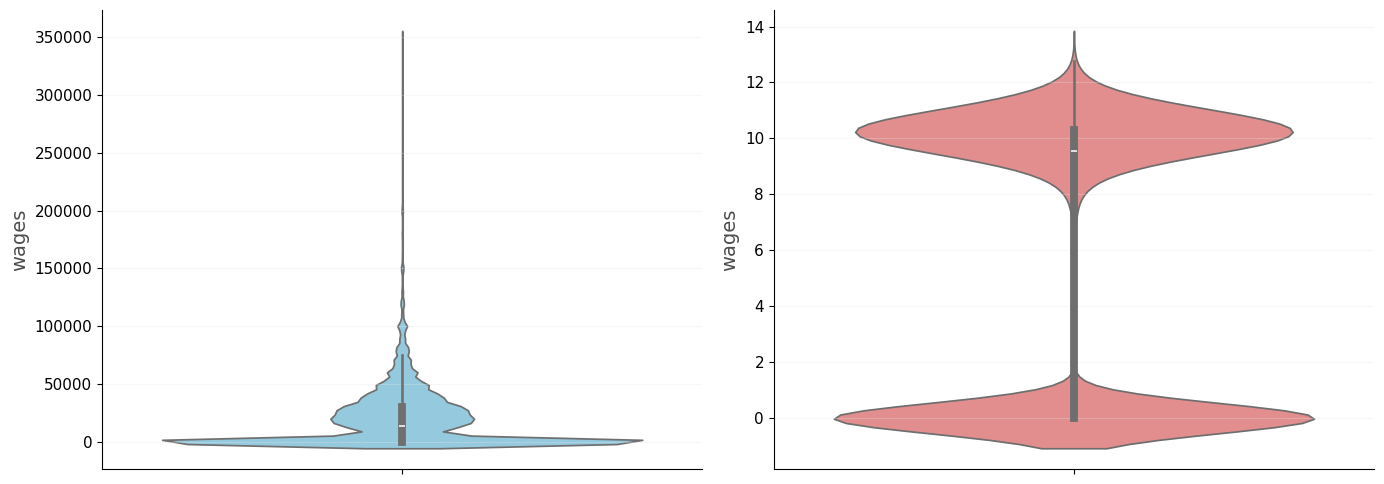

In [19]:
wages_original = panel['wages'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.violinplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.violinplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

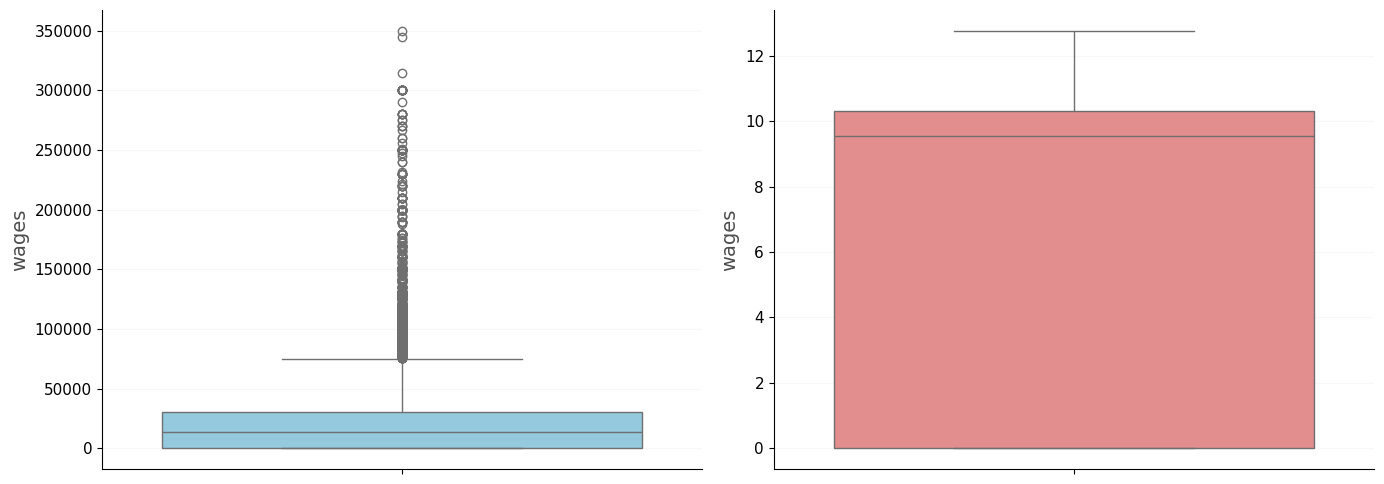

In [20]:
wages_original = panel['wages'].to_pandas()
wages_logged = np.log1p(wages_original)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))
sns.boxplot(wages_original, ax=axes[0], fill=True, color="skyblue")
sns.boxplot(wages_logged, ax=axes[1], fill=True, color="lightcoral")
plt.tight_layout()

In [21]:
common_people = panel.filter(pl.col('year') == 2019)[['idind']].join(panel.filter(pl.col('year') == 2020)[['idind']], how='inner', on='idind').sort('idind').unique()
common_people

idind
f64
36.0
60.0
125.0
126.0
127.0
…
59274.0
59275.0
59277.0


In [22]:
panel_common_2019_2020 = panel.filter(
    #pl.col('idind').is_in(common_people['idind'].implode())
).sort('idind')
panel_common_2019_2020

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,harmfull_job,job_industry,inwgt,is_employed,has_disablity,wages,period
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,f64,str,f64,str,str,str,f64,str,str,str,str,str,f64,i32,i32,f64,i32
1.0,2016.0,"""No""","""No""",0.0,0.0,47900.0,0.0,40000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",43.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""","""Yes""","""Education""",0.0,1,0,40000.0,0
1.0,2017.0,"""No""","""No""",0.0,0.0,4000.0,0.0,4000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""September""",20.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",44.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""","""Yes""","""Education""",0.0,1,0,4000.0,0
1.0,2022.0,"""Yes""","""Yes""",20000.0,0.0,67000.0,0.0,47000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""November""",22.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",49.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""","""Yes""","""Education""",0.0,1,0,47000.0,0
3.0,2017.0,"""Yes""","""Yes""",17000.0,0.0,37000.0,0.0,20000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""Third group""","""Yes""",2007.0,"""September""",20.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",62.5,"""10 and more grades of school &…","""Widower or widow""","""FEMALE""","""No""","""Public Health""",0.771486,1,1,20000.0,0
3.0,2021.0,"""Yes""","""Yes""",24000.0,0.0,34000.0,0.0,0.0,0.0,"""No""","""You are not working""","""No""","""No""","""No""","""No""","""Third group""","""Yes""",2010.0,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",66.5,"""10 and more grades of school &…","""Widower or widow""","""FEMALE""","""No""",null,0.737346,0,1,0.0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
65318.0,2024.0,"""No""","""No""",0.0,0.0,76000.0,0.0,52000.0,15000.0,"""No""","""You are currently working""","""No""","""No""","""Yes""","""No""","""No""","""No""",null,"""December""",15.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",39.0,"""Secondary School Diploma""","""Living together, not registere…","""FEMALE""","""No""","""Light Insdustry, Food Industry""",1.101734,1,0,67000.0,0
65327.0,2024.0,"""No""","""No""",0.0,0.0,38000.0,0.0,38000.0,0.0,"""No""","""You are currently working""","""No""","""No""","""No""","""No""","""No""","""No""",null,"""December""",22.0,"""Moscow Oblast""","""rural""","""Moscovskaya Oblast""",43.5,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""Education""",1.151123,1,0,38000.0,0
65335.0,2024.0,"""No""","""No""",0.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are not working""","""No""","""Yes""","""No""","""No""","""No""","""No""",null,"""December""",31.0,"""Moscow Oblast""","""rural""","""Moscovskaya Oblast""",26.0,"""Institute, University, Academy…","""In a registered marriage""","""FEMALE""","""No""",null,1.107675,0,0,0.0,0


In [23]:
education_levels = pl.read_excel('../data/all_education_levels.xlsx', sheet_name='selected_levels')
marital_status = pl.read_excel('../data/all_marst_levels.xlsx', sheet_name='selected_levels')
period_relevance = pl.read_excel('../data/period_relevance.xlsx').with_columns(
    pl.col('year').cast(pl.Float64)
)
is_town = pl.read_excel('../data/is_town.xlsx')

In [24]:
panel_common_2019_2020 = (
    panel_common_2019_2020
        .join(education_levels, on='educ', how='left', validate='m:1')
        .with_columns(pl.col('educ_level').fill_null('school_or_less'))
        .join(marital_status, on='marst', how='left', validate='m:1')
        .join(period_relevance, on='year', how='left', validate='m:1')
        .join(is_town, right_on='status', left_on='habitat', how='left', validate='m:1')
        .with_columns(pl.col('is_married').fill_null(0))
        .with_columns(
            is_female = pl.when(pl.col('gender') == 'FEMALE').then(1).otherwise(0),
        ).with_columns(
            pl.when(pl.col('hearing_disability') == 'Yes').then(1).otherwise(0).alias('hearing_disability'),
            pl.when(pl.col('eye_disability') == 'Yes').then(1).otherwise(0).alias('eye_disability'),
            pl.when(pl.col('spinal_disability') == 'Yes').then(1).otherwise(0).alias('spinal_disability'),
            pl.when(pl.col('neuro_disability') == 'Yes').then(1).otherwise(0).alias('neuro_disability'),
        )
        #.filter(pl.col('idind').is_in(common_people))
)#.drop(cols_disease) 
panel_common_2019_2020

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,harmfull_job,job_industry,inwgt,is_employed,has_disablity,wages,period,educ_level,is_married,period_relevance,is_town,is_female
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,i32,i32,i32,i32,str,str,f64,str,f64,str,str,str,f64,str,str,str,str,str,f64,i32,i32,f64,i32,str,i64,i64,i64,i32
1.0,2016.0,"""No""","""No""",0.0,0.0,47900.0,0.0,40000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",43.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""","""Yes""","""Education""",0.0,1,0,40000.0,0,"""university""",0,-4,1,1
1.0,2017.0,"""No""","""No""",0.0,0.0,4000.0,0.0,4000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",20.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",44.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""","""Yes""","""Education""",0.0,1,0,4000.0,0,"""university""",0,-3,1,1
1.0,2022.0,"""Yes""","""Yes""",20000.0,0.0,67000.0,0.0,47000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""November""",22.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",49.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""","""Yes""","""Education""",0.0,1,0,47000.0,0,"""university""",0,2,1,1
3.0,2017.0,"""Yes""","""Yes""",17000.0,0.0,37000.0,0.0,20000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""Third group""","""Yes""",2007.0,"""September""",20.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",62.5,"""10 and more grades of school &…","""Widower or widow""","""FEMALE""","""No""","""Public Health""",0.771486,1,1,20000.0,0,"""higher""",0,-3,1,1
3.0,2021.0,"""Yes""","""Yes""",24000.0,0.0,34000.0,0.0,0.0,0.0,"""No""","""You are not working""",0,0,0,0,"""Third group""","""Yes""",2010.0,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",66.5,"""10 and more grades of school &…","""Widower or widow""","""FEMALE""","""No""",null,0.737346,0,1,0.0,0,"""higher""",0,1,1,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
65318.0,2024.0,"""No""","""No""",0.0,0.0,76000.0,0.0,52000.0,15000.0,"""No""","""You are currently working""",0,0,1,0,"""No""","""No""",null,"""December""",15.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",39.0,"""Secondary School Diploma""","""Living together, not registere…","""FEMALE""","""No""","""Light Insdustry, Food Industry""",1.101734,1,0,67000.0,0,"""common""",1,4,1,1
65327.0,2024.0,"""No""","""No""",0.0,0.0,38000.0,0.0,38000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",22.0,"""Moscow Oblast""","""rural""","""Moscovskaya Oblast""",43.5,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""Education""",1.151123,1,0,38000.0,0,"""common""",1,4,0,1
65335.0,2024.0,"""No""","""No""",0.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are not working""",0,1,0,0,"""No""","""No""",null,"""December""",31.0,"""Moscow Oblast""","""rural""","""Moscovskaya Oblast""",26.0,"""Institute, University, Academy…","""In a registered marriage""","""FEMALE""","""No""",null,1.107675,0,0,0.0,0,"""university""",1,4,0,1


In [25]:
(
    panel_common_2019_2020[['year', 'has_disablity']]
    .group_by('year').agg(pl.col('has_disablity').sum())
    .sort('year')
)

year,has_disablity
f64,i32
2015.0,608
2016.0,581
2017.0,654
2018.0,586
2019.0,671
2020.0,684
2021.0,626
2022.0,628
2023.0,571


In [26]:
working_statuses = (
    panel_common_2019_2020[['idind', 'year', 'is_employed']]
    .pivot(index='idind', on='year', values='is_employed')
                   )
working_statuses

idind,2016.0,2017.0,2022.0,2021.0,2023.0,2019.0,2018.0,2020.0,2015.0,2024.0
f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
1.0,1,1,1,null,null,null,null,null,null,null
3.0,null,1,null,0,1,null,null,null,null,null
5.0,null,1,null,null,null,null,null,null,null,null
6.0,null,1,null,1,null,null,null,null,null,null
7.0,null,0,0,0,0,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…
65318.0,null,null,null,null,null,null,null,null,null,1
65327.0,null,null,null,null,null,null,null,null,null,1
65335.0,null,null,null,null,null,null,null,null,null,0


In [27]:
working_statuses_1 = working_statuses.filter(
    (pl.col('2019.0') == 1) | (pl.col('2020.0') == 1)
)
working_statuses_1

idind,2016.0,2017.0,2022.0,2021.0,2023.0,2019.0,2018.0,2020.0,2015.0,2024.0
f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
29.0,null,0,null,1,null,null,null,1,null,null
30.0,null,null,null,1,null,1,null,null,null,null
37.0,null,null,null,null,null,null,null,1,null,null
38.0,0,null,null,1,null,1,null,null,null,null
48.0,1,null,null,null,null,null,null,1,null,null
…,…,…,…,…,…,…,…,…,…,…
60467.0,null,null,1,1,null,null,null,1,null,null
60469.0,null,null,null,null,null,null,null,1,null,null
60470.0,null,null,null,null,null,null,null,1,null,null


In [28]:
disability_statuses = (
    panel_common_2019_2020[['idind', 'year', 'has_disablity']]
    .pivot(index='idind', on='year', values='has_disablity')
                   )
disability_statuses

idind,2016.0,2017.0,2022.0,2021.0,2023.0,2019.0,2018.0,2020.0,2015.0,2024.0
f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
1.0,0,0,0,null,null,null,null,null,null,null
3.0,null,1,null,1,1,null,null,null,null,null
5.0,null,0,null,null,null,null,null,null,null,null
6.0,null,0,null,0,null,null,null,null,null,null
7.0,null,1,1,1,1,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…
65318.0,null,null,null,null,null,null,null,null,null,0
65327.0,null,null,null,null,null,null,null,null,null,0
65335.0,null,null,null,null,null,null,null,null,null,0


In [29]:
disability_statuses_common = disability_statuses.filter(
    (pl.col('2019.0') == 1) | (pl.col('2020.0') == 1)
)
disability_statuses_common

idind,2016.0,2017.0,2022.0,2021.0,2023.0,2019.0,2018.0,2020.0,2015.0,2024.0
f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
132.0,null,1,null,null,null,1,null,1,null,null
178.0,1,1,null,null,null,null,null,1,null,null
188.0,null,1,null,1,null,null,null,1,null,null
305.0,null,0,null,1,0,null,0,1,0,null
329.0,null,1,1,null,null,null,1,1,null,0
…,…,…,…,…,…,…,…,…,…,…
60434.0,null,null,null,1,1,null,null,1,null,1
60436.0,null,null,null,null,null,null,null,1,null,null
60443.0,null,null,1,null,null,null,null,1,null,1


In [30]:
panel_common_2019_2020 = panel_common_2019_2020.with_columns(
    pl.when(pl.col('idind').is_in(disability_statuses_common['idind'].implode()))
    .then(1).otherwise(0).alias('has_disability_common')
)
panel_common_2019_2020

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,harmfull_job,job_industry,inwgt,is_employed,has_disablity,wages,period,educ_level,is_married,period_relevance,is_town,is_female,has_disability_common
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,i32,i32,i32,i32,str,str,f64,str,f64,str,str,str,f64,str,str,str,str,str,f64,i32,i32,f64,i32,str,i64,i64,i64,i32,i32
1.0,2016.0,"""No""","""No""",0.0,0.0,47900.0,0.0,40000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""November""",1.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",43.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""","""Yes""","""Education""",0.0,1,0,40000.0,0,"""university""",0,-4,1,1,0
1.0,2017.0,"""No""","""No""",0.0,0.0,4000.0,0.0,4000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",20.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",44.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""","""Yes""","""Education""",0.0,1,0,4000.0,0,"""university""",0,-3,1,1,0
1.0,2022.0,"""Yes""","""Yes""",20000.0,0.0,67000.0,0.0,47000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""November""",22.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",49.0,"""Institute, University, Academy…","""Divorsed and not remarried""","""FEMALE""","""Yes""","""Education""",0.0,1,0,47000.0,0,"""university""",0,2,1,1,0
3.0,2017.0,"""Yes""","""Yes""",17000.0,0.0,37000.0,0.0,20000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""Third group""","""Yes""",2007.0,"""September""",20.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",62.5,"""10 and more grades of school &…","""Widower or widow""","""FEMALE""","""No""","""Public Health""",0.771486,1,1,20000.0,0,"""higher""",0,-3,1,1,0
3.0,2021.0,"""Yes""","""Yes""",24000.0,0.0,34000.0,0.0,0.0,0.0,"""No""","""You are not working""",0,0,0,0,"""Third group""","""Yes""",2010.0,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",66.5,"""10 and more grades of school &…","""Widower or widow""","""FEMALE""","""No""",null,0.737346,0,1,0.0,0,"""higher""",0,1,1,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
65318.0,2024.0,"""No""","""No""",0.0,0.0,76000.0,0.0,52000.0,15000.0,"""No""","""You are currently working""",0,0,1,0,"""No""","""No""",null,"""December""",15.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",39.0,"""Secondary School Diploma""","""Living together, not registere…","""FEMALE""","""No""","""Light Insdustry, Food Industry""",1.101734,1,0,67000.0,0,"""common""",1,4,1,1,0
65327.0,2024.0,"""No""","""No""",0.0,0.0,38000.0,0.0,38000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",22.0,"""Moscow Oblast""","""rural""","""Moscovskaya Oblast""",43.5,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""Education""",1.151123,1,0,38000.0,0,"""common""",1,4,0,1,0
65335.0,2024.0,"""No""","""No""",0.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are not working""",0,1,0,0,"""No""","""No""",null,"""December""",31.0,"""Moscow Oblast""","""rural""","""Moscovskaya Oblast""",26.0,"""Institute, University, Academy…","""In a registered marriage""","""FEMALE""","""No""",null,1.107675,0,0,0.0,0,"""university""",1,4,0,1,0


In [31]:
(
    panel_common_2019_2020
    .filter(pl.col('idind').is_in(working_statuses_1['idind'].implode()))
    
)

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,harmfull_job,job_industry,inwgt,is_employed,has_disablity,wages,period,educ_level,is_married,period_relevance,is_town,is_female,has_disability_common
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,i32,i32,i32,i32,str,str,f64,str,f64,str,str,str,f64,str,str,str,str,str,f64,i32,i32,f64,i32,str,i64,i64,i64,i32,i32
29.0,2017.0,"""No""","""No""",0.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are not working""",0,0,0,0,"""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",46.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""","""No""",null,0.0,0,0,0.0,0,"""higher""",0,-3,1,1,0
29.0,2020.0,"""No""","""No""",0.0,0.0,43000.0,0.0,43000.0,0.0,"""Yes""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",49.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""","""No""","""Services to the General Public""",0.0,1,0,43000.0,1,"""higher""",0,0,1,1,0
29.0,2021.0,"""Yes""","""Yes""",11300.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",18.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",50.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""","""No""","""Services to the General Public""",0.0,1,0,0.0,0,"""higher""",0,1,1,1,0
30.0,2019.0,"""No""","""No""",0.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""November""",3.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",25.0,"""10 and more grades of school w…","""Never married""","""MALE""","""No""","""Wood, Timber, and Forestry""",0.0,1,0,0.0,0,"""higher""",0,-1,1,0,0
30.0,2021.0,"""No""","""No""",0.0,0.0,0.0,0.0,100000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",21.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",26.5,"""10 and more grades of school w…","""Never married""","""MALE""","""No""","""Wood, Timber, and Forestry""",0.0,1,0,100000.0,0,"""higher""",0,1,1,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
60470.0,2020.0,"""No""","""No""",0.0,0.0,55000.0,0.0,55000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""November""",30.0,"""Moscow Oblast""","""town""","""Moscovskaya Oblast""",56.5,null,"""In a registered marriage""","""MALE""","""No""","""Army, Ministry of Internal Aff…",1.114872,1,0,55000.0,1,"""school_or_less""",1,0,1,0,0
60473.0,2020.0,"""No""","""No""",0.0,0.0,40000.0,0.0,40000.0,0.0,"""Yes""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",1.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",46.5,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""Sports, Tourism, and Entertain…",0.942376,1,0,40000.0,1,"""common""",1,0,1,1,0
60473.0,2021.0,"""No""","""No""",0.0,0.0,55000.0,0.0,35000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",24.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",47.5,"""Technical, medical, musis etc …","""Living together, not registere…","""FEMALE""","""No""","""Light Insdustry, Food Industry""",0.92119,1,0,35000.0,0,"""common""",1,1,1,1,0


In [32]:
(
    panel_common_2019_2020
        #.filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        #.filter(pl.col('h7_2').is_in(['October', 'November', 'December']))
        .filter(pl.col('idind').is_in(working_statuses_1['idind'].implode()))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col('wages').mean())
).plot.line(x='year', y='wages', color='has_disablity')

alt.Chart(...)

In [33]:
# (
#     panel_common_2019_2020
#         #.filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
#         #.filter(pl.col('h7_2').is_in(['October', 'November', 'December']))
#         .filter(pl.col('idind').is_in(working_statuses_1['idind'].implode()))
#         .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
#         .group_by(['year', 'has_disability_common']).agg(pl.col('wages').mean())
# ).plot.line(x='year', y='wages', color='has_disability_common')

In [34]:
working_data = (
    panel_common_2019_2020
    .filter(pl.col('idind').is_in(working_statuses_1['idind'].implode()))
    #.filter(~pl.col('idind').is_in([33674.0, 58780.0]))
    .sort(['idind', 'year'])
)
working_data

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,harmfull_job,job_industry,inwgt,is_employed,has_disablity,wages,period,educ_level,is_married,period_relevance,is_town,is_female,has_disability_common
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,i32,i32,i32,i32,str,str,f64,str,f64,str,str,str,f64,str,str,str,str,str,f64,i32,i32,f64,i32,str,i64,i64,i64,i32,i32
29.0,2017.0,"""No""","""No""",0.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are not working""",0,0,0,0,"""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",46.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""","""No""",null,0.0,0,0,0.0,0,"""higher""",0,-3,1,1,0
29.0,2020.0,"""No""","""No""",0.0,0.0,43000.0,0.0,43000.0,0.0,"""Yes""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",49.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""","""No""","""Services to the General Public""",0.0,1,0,43000.0,1,"""higher""",0,0,1,1,0
29.0,2021.0,"""Yes""","""Yes""",11300.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",18.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",50.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""","""No""","""Services to the General Public""",0.0,1,0,0.0,0,"""higher""",0,1,1,1,0
30.0,2019.0,"""No""","""No""",0.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""November""",3.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",25.0,"""10 and more grades of school w…","""Never married""","""MALE""","""No""","""Wood, Timber, and Forestry""",0.0,1,0,0.0,0,"""higher""",0,-1,1,0,0
30.0,2021.0,"""No""","""No""",0.0,0.0,0.0,0.0,100000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",21.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",26.5,"""10 and more grades of school w…","""Never married""","""MALE""","""No""","""Wood, Timber, and Forestry""",0.0,1,0,100000.0,0,"""higher""",0,1,1,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
60470.0,2020.0,"""No""","""No""",0.0,0.0,55000.0,0.0,55000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""November""",30.0,"""Moscow Oblast""","""town""","""Moscovskaya Oblast""",56.5,null,"""In a registered marriage""","""MALE""","""No""","""Army, Ministry of Internal Aff…",1.114872,1,0,55000.0,1,"""school_or_less""",1,0,1,0,0
60473.0,2020.0,"""No""","""No""",0.0,0.0,40000.0,0.0,40000.0,0.0,"""Yes""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",1.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",46.5,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""Sports, Tourism, and Entertain…",0.942376,1,0,40000.0,1,"""common""",1,0,1,1,0
60473.0,2021.0,"""No""","""No""",0.0,0.0,55000.0,0.0,35000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",24.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",47.5,"""Technical, medical, musis etc …","""Living together, not registere…","""FEMALE""","""No""","""Light Insdustry, Food Industry""",0.92119,1,0,35000.0,0,"""common""",1,1,1,1,0


In [35]:
(
    working_data
        #.filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        #.filter(pl.col('h7_2').is_in(['October', 'November', 'December']))
        .filter(pl.col('idind').is_in(working_statuses_1['idind'].implode()))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col('wages').mean())
).plot.line(x='year', y='wages', color='has_disablity')

alt.Chart(...)

In [42]:
working_data

idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,income_decrease_bc_covid,work_status,hearing_disability,eye_disability,spinal_disability,neuro_disability,disability_class,has_disability,registred_as_disabled,month,wave,region,habitat,psu,age,educ,marst,gender,harmfull_job,job_industry,inwgt,is_employed,has_disablity,wages,period,educ_level,is_married,period_relevance,is_town,is_female,has_disability_common
f64,f64,str,str,f64,f64,f64,f64,f64,f64,str,str,i32,i32,i32,i32,str,str,f64,str,f64,str,str,str,f64,str,str,str,str,str,f64,i32,i32,f64,i32,str,i64,i64,i64,i32,i32
29.0,2017.0,"""No""","""No""",0.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are not working""",0,0,0,0,"""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",46.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""","""No""",null,0.0,0,0,0.0,0,"""higher""",0,-3,1,1,0
29.0,2020.0,"""No""","""No""",0.0,0.0,43000.0,0.0,43000.0,0.0,"""Yes""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",27.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",49.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""","""No""","""Services to the General Public""",0.0,1,0,43000.0,1,"""higher""",0,0,1,1,0
29.0,2021.0,"""Yes""","""Yes""",11300.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",18.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",50.0,"""10 and more grades of school &…","""Divorsed and not remarried""","""FEMALE""","""No""","""Services to the General Public""",0.0,1,0,0.0,0,"""higher""",0,1,1,1,0
30.0,2019.0,"""No""","""No""",0.0,0.0,0.0,0.0,0.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""November""",3.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",25.0,"""10 and more grades of school w…","""Never married""","""MALE""","""No""","""Wood, Timber, and Forestry""",0.0,1,0,0.0,0,"""higher""",0,-1,1,0,0
30.0,2021.0,"""No""","""No""",0.0,0.0,0.0,0.0,100000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""September""",21.0,"""Leningrad Oblast: Volosovkij R…","""PGT""","""Volosovkij Rajon: Leningradska…",26.5,"""10 and more grades of school w…","""Never married""","""MALE""","""No""","""Wood, Timber, and Forestry""",0.0,1,0,100000.0,0,"""higher""",0,1,1,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
60470.0,2020.0,"""No""","""No""",0.0,0.0,55000.0,0.0,55000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""November""",30.0,"""Moscow Oblast""","""town""","""Moscovskaya Oblast""",56.5,null,"""In a registered marriage""","""MALE""","""No""","""Army, Ministry of Internal Aff…",1.114872,1,0,55000.0,1,"""school_or_less""",1,0,1,0,0
60473.0,2020.0,"""No""","""No""",0.0,0.0,40000.0,0.0,40000.0,0.0,"""Yes""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",1.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",46.5,"""Technical, medical, musis etc …","""In a registered marriage""","""FEMALE""","""No""","""Sports, Tourism, and Entertain…",0.942376,1,0,40000.0,1,"""common""",1,0,1,1,0
60473.0,2021.0,"""No""","""No""",0.0,0.0,55000.0,0.0,35000.0,0.0,"""No""","""You are currently working""",0,0,0,0,"""No""","""No""",null,"""December""",24.0,"""Moscow Oblast""","""PGT""","""Moscovskaya Oblast""",47.5,"""Technical, medical, musis etc …","""Living together, not registere…","""FEMALE""","""No""","""Light Insdustry, Food Industry""",0.92119,1,0,35000.0,0,"""common""",1,1,1,1,0


In [39]:
(
    working_data
    .filter(pl.col('has_disablity') == 1)
    ['job_industry'].value_counts()
    .sort('count')
)

job_industry,count
str,u32
"""Ecology and Environmental Prot…",1
"""Real Estate Operations""",1
"""Public Organizations, Council …",2
"""Mass Media, Publishing, Printi…",2
"""Advertising and Marketing""",3
…,…
"""Construction""",39
"""Education""",44
"""Public Health""",57


In [41]:
(
    working_data
    .filter(pl.col('has_disablity') == 0)
    ['job_industry'].value_counts()
    .sort('count')
)

job_industry,count
str,u32
"""Public Organizations, Council …",2
"""Church""",10
"""Catering""",26
"""Ecology and Environmental Prot…",34
"""Advertising and Marketing""",80
…,…
"""Public Health""",2016
null,2761
"""Transportation, Commmunication""",2845


In [36]:
working_data.write_parquet('../data/wages_working_data2_1.parquet')

In [278]:
working_data.filter(pl.col('has_disablity') == 1).plot.boxplot(y='wages').properties(width=100, height=350)

alt.Chart(...)

In [279]:
alt.data_transformers.enable("vegafusion")
working_data.filter(pl.col('has_disablity') == 0).plot.boxplot(y='wages').properties(width=100, height=350)

alt.Chart(...)

In [280]:
(
    working_data
    .filter(pl.col('has_disablity') == 1)
    .filter(pl.col('wages') > 120_000)
)['idind'].to_list()

[33674.0, 58780.0]

In [281]:
(
    working_data
        #.filter((pl.col('is_employed_no_disablity') == 1)|(pl.col('is_employed_has_disablity') == 1))
        #.filter(pl.col('h7_2').is_in(['October', 'November', 'December']))
        .filter(~pl.col('idind').is_in([33674.0, 58780.0]))
        .filter(pl.col('idind').is_in(working_statuses_1['idind'].implode()))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .group_by(['year', 'has_disablity']).agg(pl.col('wages').mean())
).plot.line(x='year', y='wages', color='has_disablity')

alt.Chart(...)

In [33]:
panel2019_2020 = (
    working_data
        # .filter(pl.col())
        # .filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        .filter(
            pl.col('year').is_in([2020, 2021])
        )
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        
).to_pandas().set_index(['idind', 'year'])
panel2019_2020

recieves_pension recieves_pension_30days  amount_pension  \
idind   year                                                                  
29.0    2020-01-01               No                      No             0.0   
        2021-01-01              Yes                     Yes         11300.0   
180.0   2020-01-01               No                      No             0.0   
        2021-01-01               No                      No             0.0   
434.0   2020-01-01               No                      No             0.0   
...                             ...                     ...             ...   
60467.0 2021-01-01               No                      No             0.0   
60473.0 2020-01-01               No                      No             0.0   
        2021-01-01               No                      No             0.0   
60474.0 2020-01-01              Yes                     Yes         15600.0   
        2021-01-01              Yes                     Yes         16200.0   

                    iea_income  total_income  amount_unemp_benefits  wage_j1  \
idind   year                                                                   
29.0    2020-01-01         0.0       43000.0                    0.0  43000.0   
        2021-01-01         0.0           0.0                    0.0      0.0   
180.0   2020-01-01         0.0       32000.0                    0.0  25000.0   
        2021-01-01         0.0       24000.0                    0.0  24000.0   
434.0   2020-01-01         0.0       20000.0                    0.0  10000.0   
...                        ...           ...                    ...      ...   
60467.0 2021-01-01         0.0       31000.0                    0.0      0.0   
60473.0 2020-01-01         0.0       40000.0                    0.0  40000.0   
        2021-01-01         0.0       55000.0                    0.0  35000.0   
60474.0 2020-01-01         0.0       15600.0                    0.0      0.0   
        2021-01-01         0.0       31200.0                    0.0  14000.0   

                    wage_j2 income_decrease_bc_covid  \
idind   year                                           
29.0    2020-01-01      0.0                      Yes   
        2021-01-01      0.0                       No   
180.0   2020-01-01   7000.0                       No   
        2021-01-01      0.0                       No   
434.0   2020-01-01      0.0                       No   
...                     ...                      ...   
60467.0 2021-01-01      0.0                       No   
60473.0 2020-01-01      0.0                      Yes   
        2021-01-01      0.0                       No   
60474.0 2020-01-01      0.0                       No   
        2021-01-01      0.0                       No   

                                                          work_status  ...  \
idind   year                                                           ...   
29.0    2020-01-01                          You are currently working  ...   
        2021-01-01                          You are currently working  ...   
180.0   2020-01-01                          You are currently working  ...   
        2021-01-01                          You are currently working  ...   
434.0   2020-01-01                          You are currently working  ...   
...                                                               ...  ...   
60467.0 2021-01-01  You are on paid leave: maternity leave or taki...  ...   
60473.0 2020-01-01                          You are currently working  ...   
        2021-01-01                          You are currently working  ...   
60474.0 2020-01-01                          You are currently working  ...   
        2021-01-01                          You are currently working  ...   

                    harmfull_job  is_employed  has_disablity    wages  \
idind   year                                                            
29.0    2020-01-01            No            1              0

In [34]:
model1 = PanelOLS.from_formula('np.log(wages + 1) ~ has_disablity + EntityEffects', data=panel2019_2020).fit()#.fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model1.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:      np.log(wages + 1)   R-squared:                        0.0024
Estimator:                   PanelOLS   R-squared (Between):             -0.0147
No. Observations:                4644   R-squared (Within):               0.0024
Date:                Sun, May 03 2026   R-squared (Overall):             -0.0141
Time:                        13:48:59   Log-likelihood                   -9448.5
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      5.5121
Entities:                        2322   P-value                           0.0190
Avg Obs:                       2.0000   Distribution:                  F(1,2321)
Min Obs:                       2.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.5121
                            

In [35]:
model3 = PanelOLS.from_formula('wages ~ has_disablity + EntityEffects', data=panel2019_2020).fit(cov_type='clustered', cluster_entity=True, group_debias=False)
print(model3.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                        0.0016
Estimator:                   PanelOLS   R-squared (Between):             -0.0128
No. Observations:                4644   R-squared (Within):               0.0016
Date:                Sun, May 03 2026   R-squared (Overall):             -0.0119
Time:                        13:49:07   Log-likelihood                -4.909e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.7555
Entities:                        2322   P-value                           0.0528
Avg Obs:                       2.0000   Distribution:                  F(1,2321)
Min Obs:                       2.0000                                           
Max Obs:                       2.0000   F-statistic (robust):             5.6344
                            

In [36]:
-1.493e+04

-14930.0

In [37]:
panel2019_2020 = (
    working_data
        # .filter(pl.col())
        #.filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        #.with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
        .with_columns(
            period = pl.when(pl.col('year') == 2020).then(1).otherwise(0)
        )
).to_pandas()
panel2019_2020

,idind,year,recieves_pension,recieves_pension_30days,amount_pension,iea_income,total_income,amount_unemp_benefits,wage_j1,wage_j2,...,is_employed,has_disablity,wages,educ_level,is_married,period_relevance,is_town,is_female,has_disability_common,period
0,29.0,2017.0,No,No,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0.0,higher,0,-2,1,1,0,0
1,29.0,2020.0,No,No,0.0,0.0,43000.0,0.0,43000.0,0.0,...,1,0,43000.0,higher,0,1,1,1,0,1
2,29.0,2021.0,Yes,Yes,11300.0,0.0,0.0,0.0,0.0,0.0,...,1,0,0.0,higher,0,2,1,1,0,0
3,180.0,2015.0,No,No,0.0,3000.0,21000.0,0.0,10000.0,8000.0,...,1,0,18000.0,university,0,-4,0,1,0,0
4,180.0,2020.0,No,No,0.0,0.0,32000.0,0.0,25000.0,7000.0,...,1,0,32000.0,university,1,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13992,60467.0,2022.0,No,No,0.0,0.0,38000.0,0.0,37000.0,0.0,...,1,0,37000.0,university,0,3,1,1,0,0
13993,60473.0,2020.0,No,No,0.0,0.0,40000.0,0.0,40000.0,0.0,...,1,0,40000.0,common,1,1,1,1,0,1
13994,60473.0,2021.0,No,No,0.0,0.0,55000.0,0.0,35000.0,0.0,...,1,0,35000.0,common,1,2,1,1,0,0
13995,60474.0,2020.0,Yes,Yes,15600.0,0.0,15600.0,0.0,0.0,0.0,...,1,0,0.0,common,1,1,1,0,0,1


In [38]:
ols1 = smf.ols('wages ~ has_disability + period + I(has_disability * period)', panel2019_2020).fit()
print(ols1.summary2())

                                                       Results: Ordinary least squares
Model:                                       OLS                                      Adj. R-squared:                             0.001      
Dependent Variable:                          wages                                    AIC:                                        326180.2405
Date:                                        2026-05-03 13:49                         BIC:                                        326217.9735
No. Observations:                            13997                                    Log-Likelihood:                             -1.6309e+05
Df Model:                                    4                                        F-statistic:                                4.736      
Df Residuals:                                13992                                    Prob (F-statistic):                         0.000810   
R-squared:                                   0.001           

# event study model

In [325]:
panel_2014_2024 = (
    working_data
        #.filter(~pl.col('idind').is_in(ids_to_exclude_0 + ids_to_exclude_1))
        #.filter(~pl.col('idind').is_in(alike_matched.implode()))
        .filter(
            (pl.col('period_relevance') > -5) & (pl.col('period_relevance') < 5)
        )
        # .filter(pl.col('year').is_in([2019, 2020]))
        .with_columns(pl.col('year').cast(pl.Int32).cast(pl.String).str.to_date("%Y"))
).to_pandas()
panel_2014_2024_dta = panel_2014_2024.set_index(['idind', 'year'])
panel_2014_2024_dta

recieves_pension recieves_pension_30days  amount_pension  \
idind   year                                                                  
29.0    2017-01-01               No                      No             0.0   
        2020-01-01               No                      No             0.0   
        2021-01-01              Yes                     Yes         11300.0   
180.0   2015-01-01               No                      No             0.0   
        2020-01-01               No                      No             0.0   
...                             ...                     ...             ...   
60467.0 2022-01-01               No                      No             0.0   
60473.0 2020-01-01               No                      No             0.0   
        2021-01-01               No                      No             0.0   
60474.0 2020-01-01              Yes                     Yes         15600.0   
        2021-01-01              Yes                     Yes         16200.0   

                    iea_income  total_income  amount_unemp_benefits  wage_j1  \
idind   year                                                                   
29.0    2017-01-01         0.0           0.0                    0.0      0.0   
        2020-01-01         0.0       43000.0                    0.0  43000.0   
        2021-01-01         0.0           0.0                    0.0      0.0   
180.0   2015-01-01      3000.0       21000.0                    0.0  10000.0   
        2020-01-01         0.0       32000.0                    0.0  25000.0   
...                        ...           ...                    ...      ...   
60467.0 2022-01-01         0.0       38000.0                    0.0  37000.0   
60473.0 2020-01-01         0.0       40000.0                    0.0  40000.0   
        2021-01-01         0.0       55000.0                    0.0  35000.0   
60474.0 2020-01-01         0.0       15600.0                    0.0      0.0   
        2021-01-01         0.0       31200.0                    0.0  14000.0   

                    wage_j2 income_decrease_bc_covid  \
idind   year                                           
29.0    2017-01-01      0.0                       No   
        2020-01-01      0.0                      Yes   
        2021-01-01      0.0                       No   
180.0   2015-01-01   8000.0                       No   
        2020-01-01   7000.0                       No   
...                     ...                      ...   
60467.0 2022-01-01      0.0                       No   
60473.0 2020-01-01      0.0                      Yes   
        2021-01-01      0.0                       No   
60474.0 2020-01-01      0.0                       No   
        2021-01-01      0.0                       No   

                                  work_status  ...  gender  is_employed  \
idind   year                                   ...                        
29.0    2017-01-01        You are not working  ...  FEMALE            0   
        2020-01-01  You are currently working  ...  FEMALE            1   
        2021-01-01  You are currently working  ...  FEMALE            1   
180.0   2015-01-01  You are currently working  ...  FEMALE            1   
        2020-01-01  You are currently working  ...  FEMALE            1   
...                                       ...  ...     ...          ...   
60467.0 2022-01-01  You are currently working  ...  FEMALE            1   
60473.0 2020-01-01  You are currently working  ...  FEMALE            1   
        2021-01-01  You are currently working  ...  FEMALE            1   
60474.0 2020-01-01  You are currently working  ...    MALE            1   
        2021-01-01  You are currently working  ...    MALE            1   

                    has_disablity    wages  educ_level is_married  \
idind   year                                                        
29.0    2017-01-01              0      0.0      higher          0   
        2020-01-01              0  430

In [340]:
event_study_terms = []
for p in sorted(panel_2014_2024['period_relevance'].unique()):
    if p != 0:  # Exclude reference period
        col_name = f'rel_period_{p}_treated'
        # Create interaction: (relative_period == p) * treatment
        panel_2014_2024_dta[col_name] = ((panel_2014_2024['period_relevance'].values == p) & (panel_2014_2024['has_disability_common'].values == 1)).astype(int)
        event_study_terms.append(col_name)

X_event = panel_2014_2024_dta[event_study_terms]
#y_event = np.log1p(panel_2014_2024_dta['wages'])
y_event = panel_2014_2024_dta['wages']

event_study_model = PanelOLS(y_event, X_event, entity_effects=True, time_effects=False, check_rank=False).fit(cov_type='clustered', cluster_entity=True)
print(event_study_model.summary)

wald_test_for_period_insignificance(event_study_model)

                          PanelOLS Estimation Summary                           
Dep. Variable:                  wages   R-squared:                       -2.8467
Estimator:                   PanelOLS   R-squared (Between):             -3.2687
No. Observations:               12790   R-squared (Within):              -0.3923
Date:                Sun, Apr 26 2026   R-squared (Overall):             -2.2506
Time:                        12:52:03   Log-likelihood                -1.504e+05
Cov. Estimator:             Clustered                                           
                                        F-statistic:                     -1105.9
Entities:                        2322   P-value                           1.0000
Avg Obs:                       5.5082   Distribution:                 F(7,10461)
Min Obs:                       2.0000                                           
Max Obs:                       9.0000   F-statistic (robust):             8.1253
                            

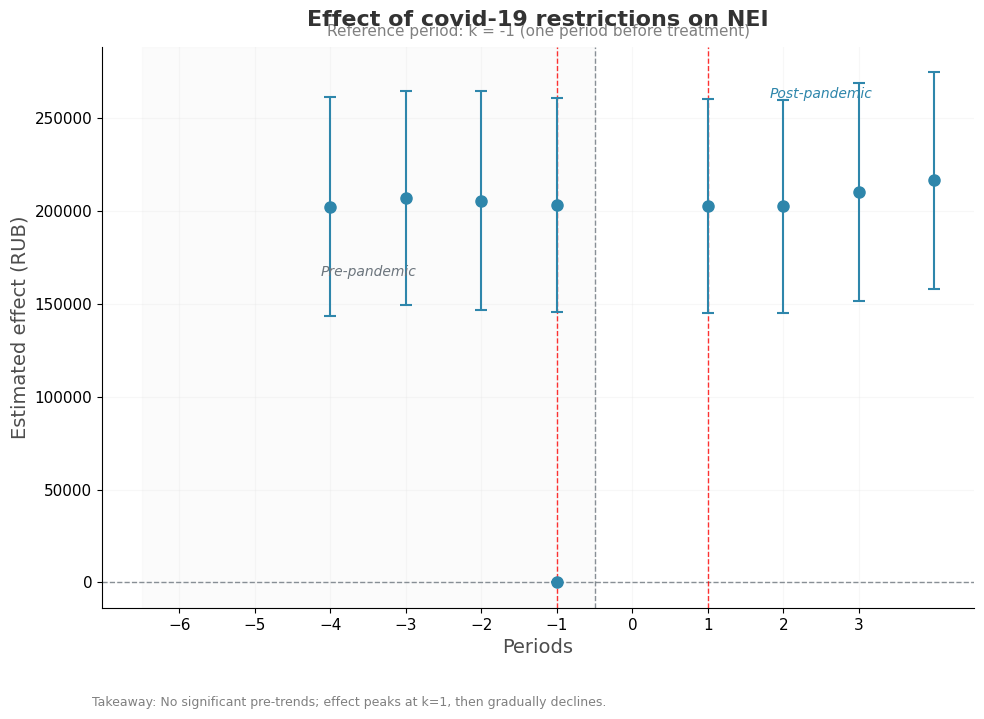

In [339]:
plot_event_margins(event_study_model_reduced)